In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [2]:
DATA_DIR = Path("../Data")
LOG_RETURNS_FILE = DATA_DIR / "crypto_and_crix_log_returns.csv"
EVENT_DATES_FILE = DATA_DIR / "event_dates.csv"
ASSET_TICKER = "ETH"
MARKET_INDEX_TICKER = "CRIX"

EVENT_MARKET_MODEL_RESULTS_FILE = DATA_DIR / "event_market_model_results.csv"
PRE_EVENT_ABNORMAL_LOG_RETURNS_FILE = DATA_DIR / "pre_event_abnormal_log_returns.csv"
ETH_EVENT_WINDOW_LOG_RETURNS_FILE = DATA_DIR / "eth_event_window_log_returns.csv"
CRIX_EVENT_WINDOW_LOG_RETURNS_FILE = DATA_DIR / "crix_event_window_log_returns.csv"
ETH_ABNORMAL_LOG_RETURNS_FILE = DATA_DIR / "eth_abnormal_log_returns.csv"

ESTIMATION_WINDOW_START = 37
ESTIMATION_WINDOW_END = 7

EVENT_WINDOW_BEFORE = 3
EVENT_WINDOW_AFTER = 21

Z_SCORE = 1.96

In [3]:
log_returns = pd.read_csv(
    LOG_RETURNS_FILE,
    index_col="Date",
    parse_dates=["Date"],
).sort_index()

log_returns.head()

,BTC,ETH,XRP,LTC,BCH,ZEC,BSV,DASH,XMR,CRIX
Date,,,,,,,,,,
2017-09-08,-0.022803,-0.036021,0.018019,-0.036837,-0.020231,-0.037624,0.0,-0.006283,0.014305,-0.014211
2017-09-09,-0.041201,-0.056461,-0.069312,-0.079201,-0.085411,-0.073408,0.0,-0.047761,-0.047126,-0.026125
2017-09-10,-0.024092,-0.028771,-0.034067,-0.057211,-0.054591,-0.024823,0.0,-0.032413,-0.041688,0.009530
2017-09-11,0.003545,0.010540,0.057708,0.012930,0.003663,0.007992,0.0,0.017270,0.009435,-0.015231
2017-09-12,0.007521,0.018426,0.018519,0.012851,-0.011267,0.006524,0.0,0.010638,0.007646,-0.054887


In [4]:
required_columns = [ASSET_TICKER, MARKET_INDEX_TICKER]

missing_columns = [
    column
    for column in required_columns
    if column not in log_returns.columns
]

if missing_columns:
    raise KeyError(
        f"Missing columns: {missing_columns}. "
        f"Available columns: {log_returns.columns.tolist()}"
    )

eth_crix_log_returns = (
    log_returns[required_columns]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .sort_index()
)

eth_crix_log_returns.head()

,ETH,CRIX
Date,,
2017-09-08,-0.036021,-0.014211
2017-09-09,-0.056461,-0.026125
2017-09-10,-0.028771,0.009530
2017-09-11,0.010540,-0.015231
2017-09-12,0.018426,-0.054887


In [5]:
print("Columns:")
print(eth_crix_log_returns.columns.tolist())

print("\nDate range:")
print(f"Start: {eth_crix_log_returns.index.min().date()}")
print(f"End:   {eth_crix_log_returns.index.max().date()}")

print("\nShape:")
print(eth_crix_log_returns.shape)

print("\nMissing values:")
print(eth_crix_log_returns.isna().sum())

Columns:
['ETH', 'CRIX']

Date range:
Start: 2017-09-08
End:   2024-04-07

Shape:
(2404, 2)

Missing values:
ETH     0
CRIX    0
dtype: int64


In [6]:
event_dates_df = pd.read_csv(
    EVENT_DATES_FILE,
    parse_dates=["event_date"],
)

if "event_date" not in event_dates_df.columns:
    raise KeyError("event_dates.csv must contain an 'event_date' column.")

EVENT_DATES = pd.DatetimeIndex(event_dates_df["event_date"]).normalize()

EVENT_DATES

DatetimeIndex(['2017-10-16', '2019-02-28', '2019-12-08', '2020-01-02',
               '2020-10-14', '2020-12-01', '2021-04-15', '2021-08-05',
               '2021-10-27', '2021-12-09', '2022-06-30', '2022-09-06',
               '2022-09-15', '2023-04-12', '2024-03-13'],
              dtype='datetime64[ns]', name='event_date', freq=None)

In [7]:
event_date_check = pd.DataFrame(
    {
        "event_date": EVENT_DATES,
        "exists_in_data": EVENT_DATES.isin(eth_crix_log_returns.index),
    }
)

event_date_check

,event_date,exists_in_data
0,2017-10-16,True
1,2019-02-28,True
2,2019-12-08,True
3,2020-01-02,True
4,2020-10-14,True
5,2020-12-01,True
6,2021-04-15,True
7,2021-08-05,True
8,2021-10-27,True
9,2021-12-09,True


In [8]:
def estimate_event_market_models(
    return_data,
    event_dates,
    days_before_start=37,
    days_before_end=7,
    asset_column=ASSET_TICKER,
    market_column=MARKET_INDEX_TICKER,
):
    """
    For each event date, fit the market model:

        ETH_t = alpha_i
                      + beta_i * CRIX_t
                      + epsilon_t

    using only the pre-event estimation window.

    Returns
    -------
    event_market_model_results : pd.DataFrame
        Event-level regression estimates and diagnostics.

    pre_event_abnormal_log_returns : pd.DataFrame
        Pre-event abnormal returns, one column per event.
    """
    return_data = return_data.copy()

    return_data.index = pd.to_datetime(
        return_data.index
    )

    return_data = return_data.sort_index()

    event_dates = pd.DatetimeIndex(
        pd.to_datetime(event_dates)
    )

    result_records = []
    pre_event_ar_dict = {}

    for event_date in event_dates:

        window_start = (
            event_date
            - pd.Timedelta(days=days_before_start)
        )

        window_end = (
            event_date
            - pd.Timedelta(days=days_before_end)
        )

        estimation_window = return_data.loc[
            window_start:window_end,
            [asset_column, market_column],
        ].copy()

        estimation_window = (
            estimation_window
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
        )

        if len(estimation_window) < 10:
            print(
                f"Skipping {event_date.date()}: "
                f"only {len(estimation_window)} valid observations."
            )
            continue

        if estimation_window[asset_column].nunique() < 2:
            print(
                f"Skipping {event_date.date()}: "
                f"{asset_column} is constant."
            )
            continue

        if estimation_window[market_column].nunique() < 2:
            print(
                f"Skipping {event_date.date()}: "
                f"{market_column} is constant."
            )
            continue

        X = sm.add_constant(
            estimation_window[market_column],
            has_constant="add",
        )

        y = estimation_window[asset_column]

        model = sm.OLS(y, X).fit()

        alpha = model.params["const"]
        beta = model.params[market_column]

        expected_returns = model.predict(X)
        abnormal_returns = y - expected_returns

        result_records.append(
            {
                "event_date": event_date,
                "alpha": alpha,
                "beta": beta,
                "residual_std": np.sqrt(model.mse_resid),
                "n_obs": int(model.nobs),
                "r_squared": model.rsquared,
            }
        )

        pre_event_ar_dict[event_date] = (
            abnormal_returns.reset_index(drop=True)
        )

    event_market_model_results = pd.DataFrame(result_records)

    if event_market_model_results.empty:
        raise ValueError(
            "No event regressions were successfully estimated."
        )

    event_market_model_results["event_date"] = pd.to_datetime(
        event_market_model_results["event_date"]
    )

    event_market_model_results = (
        event_market_model_results
        .sort_values("event_date")
        .reset_index(drop=True)
    )

    pre_event_abnormal_log_returns = pd.DataFrame(pre_event_ar_dict)

    return event_market_model_results, pre_event_abnormal_log_returns

In [9]:
def build_event_log_return_windows(
    return_data,
    event_dates,
    limit_before=3,
    limit_after=21,
    asset_column=ASSET_TICKER,
    market_column=MARKET_INDEX_TICKER,
):
    """
    Extract fixed-length aligned ETH and CRIX return windows.

    Relative day:
        -3 = three observations before the event
         0 = event day
       +21 = twenty-one observations after the event.
    """
    return_data = return_data.copy()

    return_data.index = pd.to_datetime(
        return_data.index
    )

    return_data = return_data.sort_index()

    event_dates = pd.DatetimeIndex(
        pd.to_datetime(event_dates)
    )

    relative_days = pd.Index(
        range(
            -int(limit_before),
            int(limit_after) + 1,
        ),
        name="relative_day",
    )

    expected_length = len(relative_days)

    asset_windows = {}
    market_windows = {}

    for event_date in event_dates:

        if event_date not in return_data.index:
            print(
                f"Skipping {event_date.date()}: "
                "event date not found."
            )
            continue

        event_position = return_data.index.get_loc(
            event_date
        )

        start_position = (
            event_position - int(limit_before)
        )

        end_position = (
            event_position + int(limit_after) + 1
        )

        if start_position < 0:
            print(
                f"Skipping {event_date.date()}: "
                "insufficient observations before event."
            )
            continue

        if end_position > len(return_data):
            print(
                f"Skipping {event_date.date()}: "
                "insufficient observations after event."
            )
            continue

        event_window = return_data.iloc[
            start_position:end_position
        ][[asset_column, market_column]].copy()

        if len(event_window) != expected_length:
            print(
                f"Skipping {event_date.date()}: "
                "incorrect window length."
            )
            continue

        if event_window.isna().any().any():
            print(
                f"Skipping {event_date.date()}: "
                "missing values in event window."
            )
            continue

        event_window.index = relative_days

        asset_windows[event_date] = (
            event_window[asset_column]
        )

        market_windows[event_date] = (
            event_window[market_column]
        )

    asset_event_returns = pd.DataFrame(asset_windows)
    market_event_returns = pd.DataFrame(market_windows)

    return asset_event_returns, market_event_returns

In [10]:
def compute_car_with_ci(
    asset_return_df,
    market_return_df,
    event_market_model_results,
    z_score=1.96,
):
    """
    Compute expected returns, abnormal returns, CAR, and
    approximate confidence bands.
    """
    asset_return_df = asset_return_df.copy()
    market_return_df = market_return_df.copy()
    event_market_model_results = event_market_model_results.copy()

    if "event_date" not in event_market_model_results.columns:
        if event_market_model_results.index.name == "event_date":
            event_market_model_results = event_market_model_results.reset_index()
        else:
            raise KeyError(
                "event_market_model_results must contain an 'event_date' column."
            )

    event_market_model_results["event_date"] = pd.to_datetime(
        event_market_model_results["event_date"]
    ).dt.normalize()

    asset_return_df.columns = pd.DatetimeIndex(
        pd.to_datetime(asset_return_df.columns)
    ).normalize()

    market_return_df.columns = pd.DatetimeIndex(
        pd.to_datetime(market_return_df.columns)
    ).normalize()

    regression_events = pd.DatetimeIndex(
        event_market_model_results["event_date"]
    )

    valid_events = (
        regression_events
        .intersection(asset_return_df.columns)
        .intersection(market_return_df.columns)
    )

    if len(valid_events) == 0:
        raise ValueError(
            "No common event dates were found across the inputs."
        )

    coefficients = (
        event_market_model_results
        .set_index("event_date")
        .loc[
            valid_events,
            ["alpha", "beta", "residual_std"],
        ]
    )

    asset_return_df = asset_return_df.loc[
        :,
        valid_events,
    ]

    market_return_df = market_return_df.loc[
        :,
        valid_events,
    ]

    expected_return_df = pd.DataFrame(
        {
            event_date: (
                coefficients.loc[event_date, "alpha"]
                + coefficients.loc[event_date, "beta"]
                * market_return_df[event_date]
            )
            for event_date in valid_events
        },
        index=market_return_df.index,
    )

    abnormal_return_df = (
        asset_return_df
        - expected_return_df
    )

    car_df = abnormal_return_df.cumsum()

    # Same style of approximate event-specific CI
    # Same style of approximate event-specific CI
    cumulative_days = np.arange(
        1,
        len(car_df.index) + 1,
    )

    # Original confidence-band calculation
    standard_error = (
        car_df.std(axis=0)
        / np.sqrt(len(car_df))
    )

    car_upper_df = (
        car_df
        + z_score * standard_error
    )

    car_lower_df = (
        car_df
        - z_score * standard_error
    )

    return (
        expected_return_df,
        abnormal_return_df,
        car_df,
        car_upper_df,
        car_lower_df,
    )

In [11]:
def plot_car_grid(
    car_df,
    car_upper_df,
    car_lower_df,
    save_path=None,
):
    """
    Plot one CAR chart per event with shaded confidence bands.
    """
    if car_df.empty:
        raise ValueError(
            "car_df is empty. Nothing to plot."
        )

    plt.rcParams["font.family"] = "serif"

    n_events = len(car_df.columns)
    num_rows = 3
    num_cols = int(np.ceil(n_events / num_rows))

    fig, axes = plt.subplots(
        num_rows,
        num_cols,
        figsize=(4 * num_cols, 4 * num_rows),
        squeeze=False,
    )

    axes = axes.ravel()

    for idx, event_date in enumerate(car_df.columns):

        ax = axes[idx]

        ax.plot(
            car_df.index,
            car_df[event_date].values,
            color="blue",
            linewidth=2,
        )

        ax.fill_between(
            car_df.index,
            car_lower_df[event_date].values,
            car_upper_df[event_date].values,
            color="blue",
            alpha=0.3,
            linewidth=0,
        )

        ax.axvline(
            0,
            color="black",
            linewidth=1,
        )

        ax.axhline(
            0,
            color="black",
            linewidth=1,
        )

        ax.set_title(
            pd.Timestamp(event_date).strftime("%Y-%m-%d"),
            fontsize=11,
            fontweight="bold",
            loc="left",
        )

        ax.set_xlabel(
            "Days relative to event",
            fontsize=9,
        )

        ax.set_ylabel(
            "CAR",
            fontsize=9,
        )

        ax.set_xticks(car_df.index)
        ax.tick_params(
            axis="both",
            labelsize=7,
        )

        ax.set_facecolor("none")
        ax.grid(False)

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color("lightgray")
            spine.set_linewidth(1)

    for idx in range(n_events, len(axes)):
        axes[idx].axis("off")

    fig.patch.set_alpha(0)
    plt.tight_layout()

    if save_path is not None:
        fig.savefig(
            save_path,
            dpi=200,
            transparent=True,
            bbox_inches="tight",
        )

    plt.show()

    return fig

In [12]:
event_market_model_results, pre_event_abnormal_log_returns = estimate_event_market_models(
    return_data=eth_crix_log_returns,
    event_dates=EVENT_DATES,
    days_before_start=ESTIMATION_WINDOW_START,
    days_before_end=ESTIMATION_WINDOW_END,
    asset_column=ASSET_TICKER,
    market_column=MARKET_INDEX_TICKER,
)

event_market_model_results.round(6)

,event_date,alpha,beta,residual_std,n_obs,r_squared
0,2017-10-16,-0.002077,0.035590,0.046221,31,0.002368
1,2019-02-28,0.003345,0.878809,0.024526,31,0.448151
2,2019-12-08,-0.002807,0.545510,0.020911,31,0.297934
3,2020-01-02,-0.003677,0.214412,0.020320,31,0.072192
4,2020-10-14,-0.000630,0.408600,0.022845,31,0.119865
5,2020-12-01,0.008304,0.327459,0.026339,31,0.108357
6,2021-04-15,0.002984,0.445850,0.025328,31,0.250927
7,2021-08-05,0.000653,0.840731,0.028724,31,0.468836
8,2021-10-27,0.000418,0.514719,0.026793,31,0.402683
9,2021-12-09,0.002284,0.491600,0.024193,31,0.344545


In [13]:
eth_event_window_log_returns, crix_event_window_log_returns = build_event_log_return_windows(
    return_data=eth_crix_log_returns,
    event_dates=EVENT_DATES,
    limit_before=EVENT_WINDOW_BEFORE,
    limit_after=EVENT_WINDOW_AFTER,
    asset_column=ASSET_TICKER,
    market_column=MARKET_INDEX_TICKER,
)

print("ETH event-window shape:", eth_event_window_log_returns.shape)
print("CRIX event-window shape:", crix_event_window_log_returns.shape)

eth_event_window_log_returns.head()

ETH event-window shape: (25, 15)
CRIX event-window shape: (25, 15)


,2017-10-16,2019-02-28,2019-12-08,2020-01-02,2020-10-14,2020-12-01,2021-04-15,2021-08-05,2021-10-27,2021-12-09,2022-06-30,2022-09-06,2022-09-15,2023-04-12,2024-03-13
relative_day,,,,,,,,,,,,,,,
-3,0.058024,-0.105230,0.000980,0.016399,-0.000782,0.021357,0.003266,0.000000,0.008370,-0.006755,-0.020451,-0.022216,-0.017720,-0.009677,0.001789
-2,0.053679,-0.013209,0.013402,-0.017257,0.015556,0.045983,0.035236,-0.034088,0.018461,0.051656,-0.015827,0.001283,-0.042409,0.010747,0.015453
-1,-0.027612,-0.001901,-0.001047,-0.002889,0.008616,0.075998,0.058082,0.029841,0.011962,0.000919,-0.058790,0.012739,-0.038018,0.022200,0.005765
0,0.022288,0.001609,0.005577,-0.014200,-0.005503,0.015979,0.042772,0.051641,-0.030913,-0.015508,-0.070075,0.034218,-0.024037,-0.011567,0.002995
1,-0.045550,-0.002532,-0.002305,0.015493,-0.008873,-0.017572,-0.010625,0.034306,0.010492,-0.049245,0.017984,-0.055325,-0.070961,0.040420,-0.022173


In [14]:
(
    eth_expected_log_returns,
    eth_abnormal_log_returns,
    eth_cumulative_abnormal_log_returns,
    eth_car_upper_confidence_bound,
    eth_car_lower_confidence_bound,
) = compute_car_with_ci(
    asset_return_df=eth_event_window_log_returns,
    market_return_df=crix_event_window_log_returns,
    event_market_model_results=event_market_model_results,
    z_score=Z_SCORE,
)

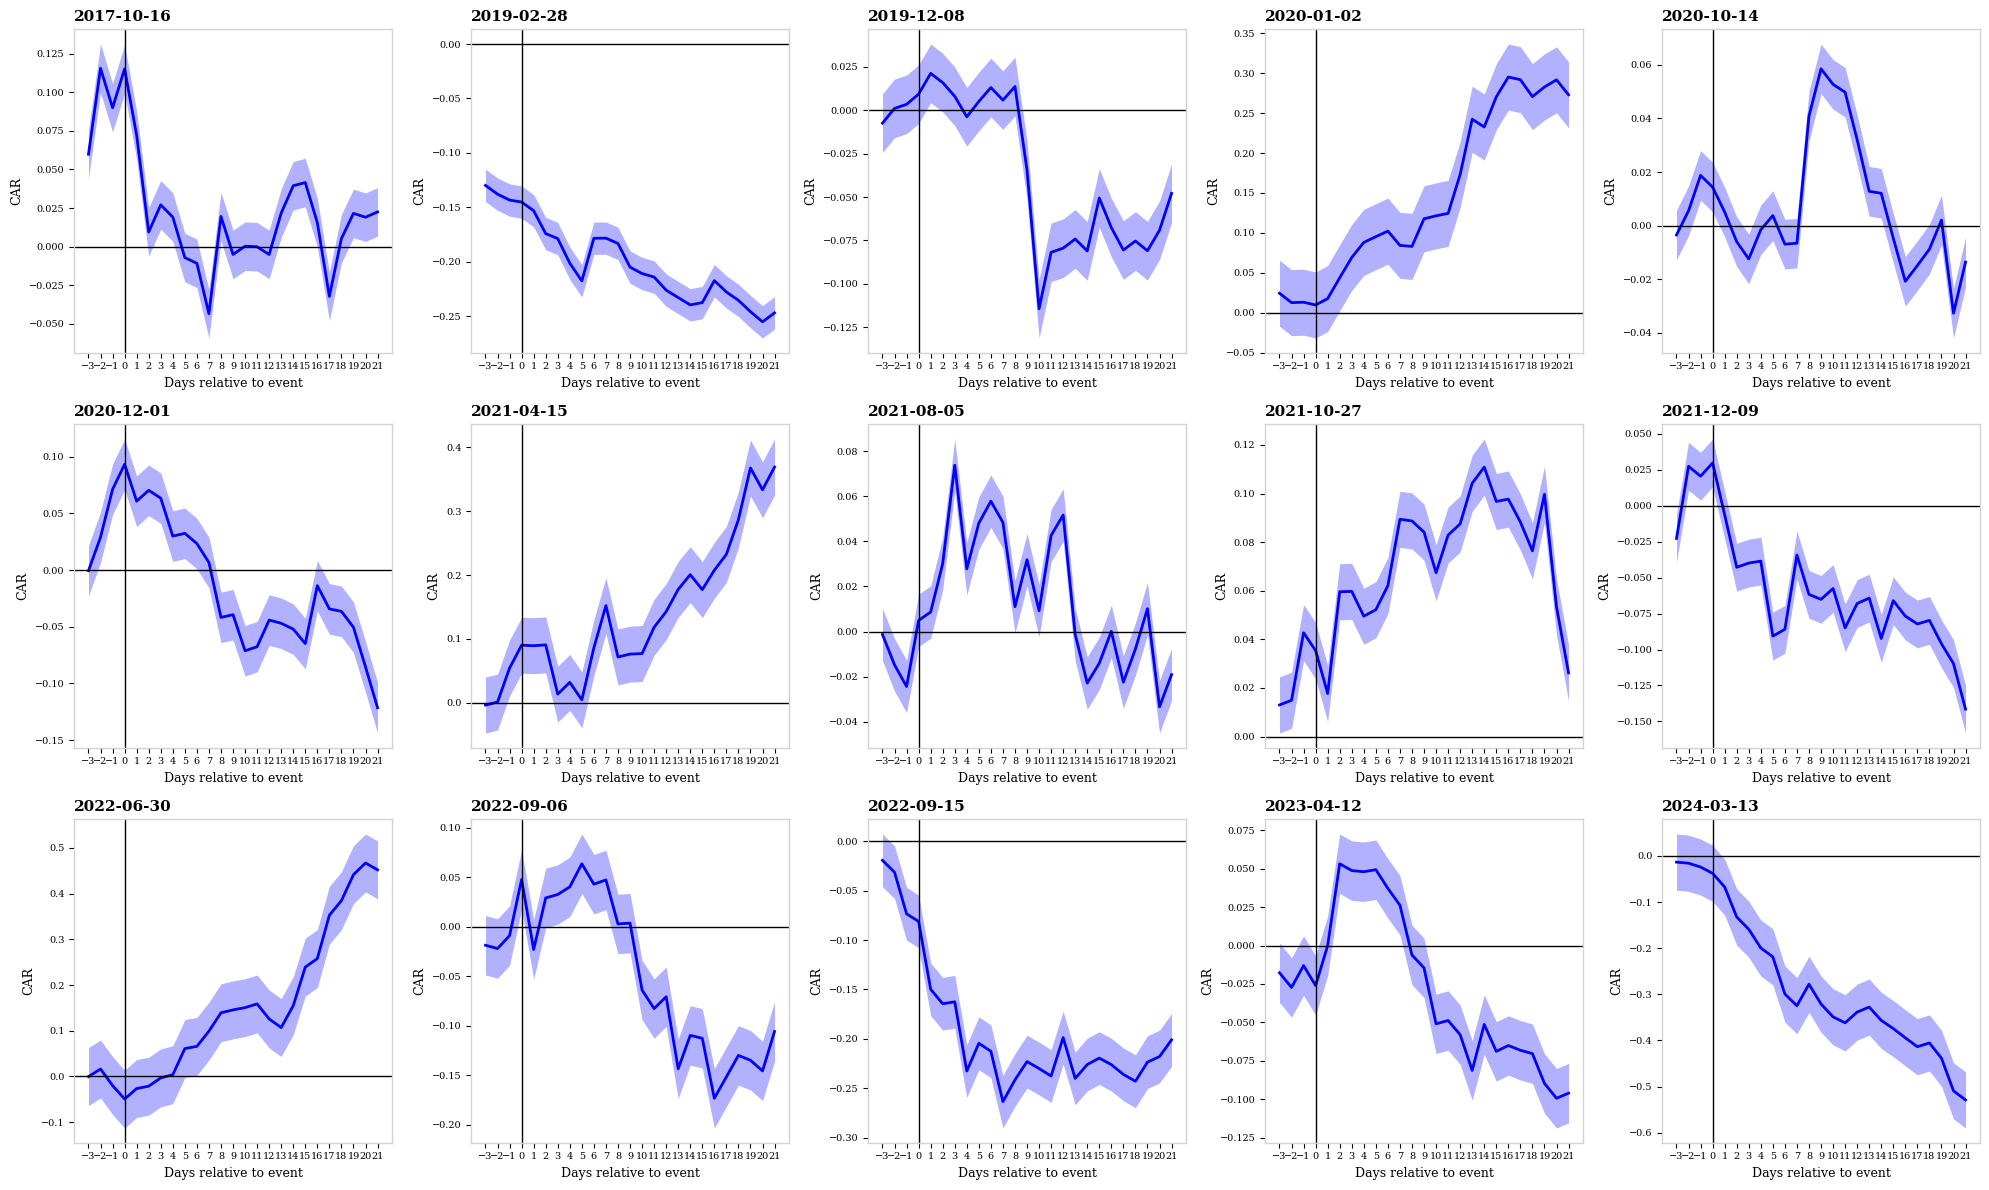

In [15]:
fig = plot_car_grid(
    car_df=eth_cumulative_abnormal_log_returns,
    car_upper_df=eth_car_upper_confidence_bound,
    car_lower_df=eth_car_lower_confidence_bound,
    save_path="car_grid.png",
)

In [16]:
# Persist reusable event-study outputs.  Each event is a column in the
# window tables, and `relative_day` is the row index (-3 through +21).
# - event_market_model_results: pre-event model coefficients and diagnostics.
# - pre_event_abnormal_log_returns: estimation-window abnormal returns.
# - eth_event_window_log_returns / crix_event_window_log_returns:
#   raw event-window log returns.
# - eth_abnormal_log_returns: ETH return minus its model-implied return.

event_market_model_results.to_csv(
    EVENT_MARKET_MODEL_RESULTS_FILE,
    index=False,
)

pre_event_abnormal_log_returns.to_csv(
    PRE_EVENT_ABNORMAL_LOG_RETURNS_FILE,
    index=True,
)

eth_event_window_log_returns.to_csv(
    ETH_EVENT_WINDOW_LOG_RETURNS_FILE,
    index=True,
)

crix_event_window_log_returns.to_csv(
    CRIX_EVENT_WINDOW_LOG_RETURNS_FILE,
    index=True,
)

eth_abnormal_log_returns.to_csv(
    ETH_ABNORMAL_LOG_RETURNS_FILE,
    index=True,
)